# Setup and Context

<img src="https://i.imgur.com/gugIA5r.png" width=700>

In [3]:
# Import the drive module from google.colab
from google.colab import drive
# Mount Google Drive to access files
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


### Introduction

Dr Ignaz Semmelweis was a Hungarian physician born in 1818 who worked in the Vienna General Hospital. In the past people thought of illness as caused by "bad air" or evil spirits. But in the 1800s Doctors started looking more at anatomy, doing autopsies and started making arguments based on data. Dr Semmelweis suspected that something was going wrong with the procedures at Vienna General Hospital. Semmelweis wanted to figure out why so many women in maternity wards were dying from childbed fever (i.e., [puerperal fever](https://en.wikipedia.org/wiki/Postpartum_infections)).

<img src=https://i.imgur.com/lSyNUwR.png width=700>

Today you will become Dr Semmelweis. This is your office 👆. You will step into Dr Semmelweis' shoes and analyse the same data collected from 1841 to 1849.

### The Data Source

Dr Semmelweis published his research in 1861. I found the scanned pages of the [full text with the original tables in German](http://www.deutschestextarchiv.de/book/show/semmelweis_kindbettfieber_1861), but an excellent [English translation can be found here](http://graphics8.nytimes.com/images/blogs/freakonomics/pdf/the%20etiology,%20concept%20and%20prophylaxis%20of%20childbed%20fever.pdf).

<img src=https://i.imgur.com/6HfLtaC.png width=500>

### Upgrade plotly (only Google Colab Notebook)

Google Colab may not be running the latest version of plotly. If you're working in Google Colab, uncomment the line below, run the cell, and restart your notebook server.

In [4]:
# Upgrade the plotly library to ensure the latest features and bug fixes
%pip install --upgrade plotly

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 64.1 MB/s eta 0:00:00
  Attempting uninstall: plotly
    Found existing installation: plotly 5.24.1
    Uninstalling plotly-5.24.1:
      Successfully uninstalled plotly-5.24.1


### Import Statements

In [5]:

import pandas as pd
import numpy as np
import plotly.express as px
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

### Notebook Presentation

In [6]:
# Set pandas display option to format float numbers with two decimal places and comma as thousands separator
pd.options.display.float_format = '{:,.2f}'.format

# Import and register matplotlib converters for pandas datetime objects
# This is necessary for matplotlib to properly handle pandas datetime data in plots
from pandas.plotting import register_matplotlib_converters
register_matplotlib_converters()

### Read the Data

In [7]:
# Read the yearly deaths data from a CSV file into a pandas DataFrame
df_yearly = pd.read_csv('/content/drive/MyDrive/annual_deaths_by_clinic.csv')
# Read the monthly deaths data from a CSV file into a pandas DataFrame
# The 'parse_dates' argument converts the 'date' column into datetime objects directly
df_monthly = pd.read_csv('/content/drive/MyDrive/monthly_deaths.csv',
                      parse_dates=['date'])

# Preliminary Data Exploration

**Challenge**: Check out these two DataFrames ☝️.
* What is the shape of df_yearly and df_monthly? How many rows and columns?
* What are the column names?
* Which years are included in the dataset?
* Are there any NaN values or duplicates?
* What were the average number of births that took place per month?
* What were the average number of deaths that took place per month?

In [8]:
# Print the shape (number of rows and columns) of df_yearly and df_monthly DataFrames
print(f'df yearly: {df_yearly.shape}\ndf monthly: {df_monthly.shape}')

df yearly: (12, 4)
df monthly: (98, 3)


In [9]:
# Print the column names of df_yearly and df_monthly DataFrames
print(f'df yearly: {df_yearly.columns}\ndf monthly: {df_monthly.columns}')

df yearly: Index(['year', 'births', 'deaths', 'clinic'], dtype='object')
df monthly: Index(['date', 'births', 'deaths'], dtype='object')


In [10]:
# Print the 'year' column from df_yearly and the 'date' column from df_monthly
print(f'df yearly: {df_yearly.year} \n\n df monthly: {df_monthly.date}')

df yearly: 0     1841
1     1842
2     1843
3     1844
4     1845
5     1846
6     1841
7     1842
8     1843
9     1844
10    1845
11    1846
Name: year, dtype: int64 

 df monthly: 0    1841-01-01
1    1841-02-01
2    1841-03-01
3    1841-04-01
4    1841-05-01
        ...    
93   1848-11-01
94   1848-12-01
95   1849-01-01
96   1849-02-01
97   1849-03-01
Name: date, Length: 98, dtype: datetime64[ns]


### Check for Nan Values and Duplicates

In [11]:
# Check for any NaN (Not a Number) values in each column of df_yearly and df_monthly
# .isna() returns a boolean DataFrame, .any() checks if any value in a column is True
print(f'df yearly: \n {df_yearly.isna().any()}\ndf monthly: \n {df_monthly.isna().any()}')

df yearly: 
 year      False
births    False
deaths    False
clinic    False
dtype: bool
df monthly: 
 date      False
births    False
deaths    False
dtype: bool


In [12]:
# Check for any duplicate rows in df_monthly and df_yearly
# .duplicated().any() returns True if any row is a duplicate, False otherwise
print(f'df_monthly : {df_monthly.duplicated().any()}\n df_yearly :{df_yearly.duplicated().any()}')

df_monthly : False
 df_yearly :False


### Descriptive Statistics

In [13]:
# Generate descriptive statistics (count, mean, std, min, 25%, 50%, 75%, max) for numerical columns
print(f'for monthly: \n{df_monthly.describe()} \n\n for yearly: \n{df_yearly.describe()}')

for monthly: 
                                date  births  deaths
count                             98   98.00   98.00
mean   1845-02-11 04:24:29.387755008  267.00   22.47
min              1841-01-01 00:00:00  190.00    0.00
25%              1843-02-08 00:00:00  242.50    8.00
50%              1845-02-15 00:00:00  264.00   16.50
75%              1847-02-22 00:00:00  292.75   36.75
max              1849-03-01 00:00:00  406.00   75.00
std                              NaN   41.77   18.14 

 for yearly: 
          year   births  deaths
count    12.00    12.00   12.00
mean  1,843.50 3,152.75  223.33
std       1.78   449.08  145.38
min   1,841.00 2,442.00   66.00
25%   1,842.00 2,901.75  100.25
50%   1,843.50 3,108.50  219.50
75%   1,845.00 3,338.25  263.50
max   1,846.00 4,010.00  518.00


### Percentage of Women Dying in Childbirth

**Challenge**: How dangerous was childbirth in the 1840s in Vienna?

* Using the annual data, calculate the percentage of women giving birth who died throughout the 1840s at the hospital.


In comparison, the United States recorded 18.5 maternal deaths per 100,000 or 0.018% in 2013 [(source).](
https://en.wikipedia.org/wiki/Maternal_death#:~:text=The%20US%20has%20the%20%22highest,17.8%20per%20100%2C000%20in%202009)

In [14]:
# Display the first 3 rows of the df_yearly DataFrame
df_yearly.head(3)

,year,births,deaths,clinic
0,1841,3036,237,clinic 1
1,1842,3287,518,clinic 1
2,1843,3060,274,clinic 1


In [15]:
# Calculate the overall percentage of deaths by summing total deaths and total births from df_yearly
# Then multiply by 100 to get a percentage and round to 2 decimal places
print(f'Chances of dying in the 1840s in Vienna\n{round((df_yearly.deaths.sum() / df_yearly.births.sum()) * 100, 2)}')

Chances of dying in the 1840s in Vienna
7.08


# Visualise the Total Number of Births 🤱 and Deaths 💀 over Time

### Plot the Monthly Data on Twin Axes

**Challenge**: Create a [Matplotlib chart](https://matplotlib.org/3.3.2/api/_as_gen/matplotlib.pyplot.plot.html) with twin y-axes. It should look something like this:

<img src=https://i.imgur.com/F9DOJxx.png width=700>

* Format the x-axis using locators for the years and months (Hint: we did this in the Google Trends notebook)
* Set the range on the x-axis so that the chart lines touch the y-axes
* Add gridlines
* Use `skyblue` and `crimson` for the line colours
* Use a dashed line style for the number of deaths
* Change the line thickness to 3 and 2 for the births and deaths respectively.
* Do you notice anything in the late 1840s?

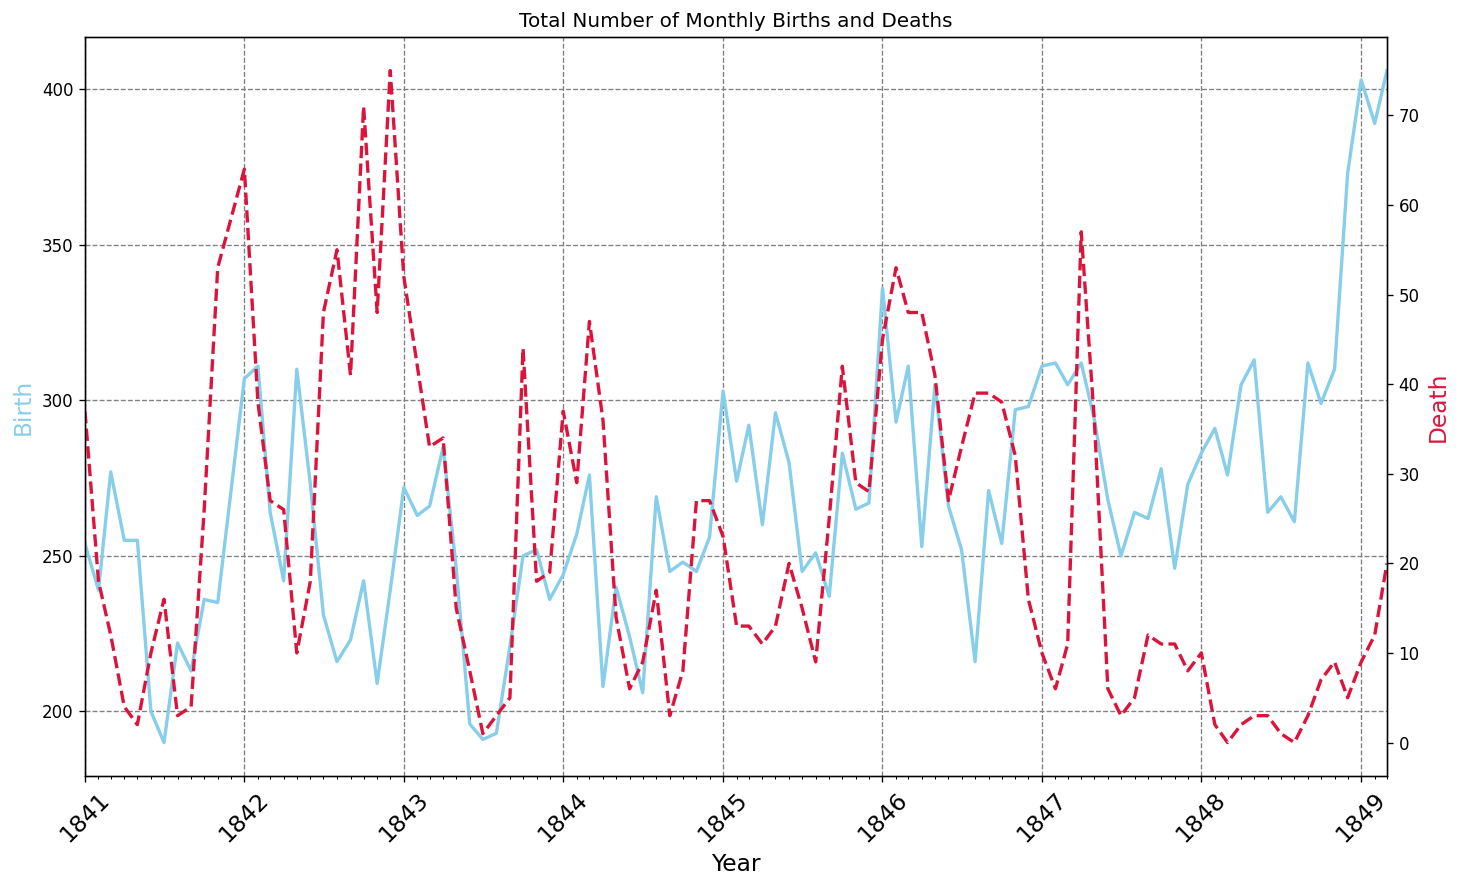

In [16]:
# Set the figure size and resolution for the matplotlib plot
plt.figure(figsize=(14,8), dpi=120)
plt.xticks(fontsize = 14, rotation=45)

ax1 = plt.gca()
ax2 = ax1.twinx()

plt.title('Total Number of Monthly Births and Deaths')

# Add grid lines to the plot with a dashed style
ax1.grid(color='grey', linestyle='--')


ax1.set_xlim([df_monthly.date.min(), df_monthly.date.max()])
ax1.xaxis.set_major_locator(mdates.YearLocator())  # Set major tick locations to yearly intervals
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y')) # Format major tick labels to display only the year
ax1.xaxis.set_minor_locator(mdates.MonthLocator()) # Set minor tick locations to monthly intervals

ax1.set_xlabel('Year', fontsize = 14)
ax1.set_ylabel('Birth', color = 'skyblue', fontsize = 14)
ax2.set_ylabel('Death', color = 'crimson', fontsize = 14)

ax1.plot(df_monthly.date, df_monthly.births, color = 'skyblue', linewidth=2)
ax2.plot(df_monthly.date, df_monthly.deaths, color = 'crimson', linewidth=2, linestyle='--')

# Display the plot
plt.show()

**Outcome**: What we see is that something happened after 1847. The total number of deaths seems to have dropped, despite an increasing number of births!

# The Yearly Data Split by Clinic

Now let's look at the annual data instead.

**Challenge**: Use plotly to create line charts of the births and deaths of the two different clinics at the Vienna General Hospital.
* Which clinic is bigger or more busy judging by the number of births?
* Has the hospital had more patients over time?
* What was the highest number of deaths recorded in clinic 1 and clinic 2?

In [17]:
# Create an interactive line chart using Plotly Express
# x-axis: 'year', y-axis: 'births', color: 'clinic' to differentiate lines
birth_fig = px.line(df_yearly, x="year", y="births", color='clinic', title='Total Yearly Births by Clinic')
# Display the plot
birth_fig.show()

**Outcome**: We see that more and more women gave birth at the hospital over the years. Clinic 1, which was staffed by male doctors and medical students was also the busier or simply the larger ward. More births took place in clinic 1 than in clinic 2.

In [18]:
# Create an interactive line chart using Plotly Express
# x-axis: 'year', y-axis: 'deaths', color: 'clinic' to differentiate lines
birth_fig = px.line(df_yearly, x="year", y="deaths", color='clinic', title='Total Yearly Deaths by Clinic')
# Display the plot
birth_fig.show()

**Outcome**: We also see that, not only were more people born in clinic 1, more people also died in clinic 1.

### Calculate the Proportion of Deaths at Each Clinic

**Challenge**: Calculate the proportion of maternal deaths per clinic. That way we can compare like with like.
* Work out the percentage of deaths for each row in the `df_yearly` DataFrame by adding a column called "pct_deaths".
* Calculate the average maternal death rate for clinic 1 and clinic 2 (i.e., the total number of deaths per the total number of births).
* Create another plotly line chart to see how the percentage varies year over year with the two different clinics.
* Which clinic has a higher proportion of deaths?
* What is the highest monthly death rate in clinic 1 compared to clinic 2?

In [19]:
# Calculate the percentage of deaths for each row in df_yearly
# deaths / births * 100, rounded to 2 decimal places
df_yearly['pct__deaths'] = round(df_yearly['deaths'] / df_yearly['births'] * 100,2)

# Display a random sample of 5 rows from the updated df_yearly DataFrame
df_yearly.sample(5)

,year,births,deaths,clinic,pct__deaths
5,1846,4010,459,clinic 1,11.45
6,1841,2442,86,clinic 2,3.52
8,1843,2739,164,clinic 2,5.99
11,1846,3754,105,clinic 2,2.80
3,1844,3157,260,clinic 1,8.24


In [20]:
# Filter df_yearly to get data for 'clinic 1'
clinic_1 = df_yearly[df_yearly.clinic == 'clinic 1']

# Calculate the average death rate for clinic 1 (total deaths / total births * 100), rounded to 2 decimal places
avg_c1 = round(clinic_1.deaths.sum() / clinic_1.births.sum() * 100, 2)

# Print the calculated average death rate for clinic 1
print(f'Average death rate in clinic 1 is {avg_c1}%.')

Average death rate in clinic 1 is 9.92%.


In [21]:
# Filter df_yearly to get data for 'clinic 2'
clinic_2 = df_yearly[df_yearly.clinic == 'clinic 2']

# Calculate the average death rate for clinic 2 (total deaths / total births * 100), rounded to 2 decimal places
avg_c2 = round(clinic_2.deaths.sum() / clinic_2.births.sum() * 100, 2)

# Print the calculated average death rate for clinic 2
print(f'Average death rate in clinic 1 is {avg_c2}%.')

Average death rate in clinic 1 is 3.88%.


**Outcome**: The average death rate for the entire time period for clinic 1 is 9.92%. In comparison, clinic 2 which was staffed by midwives had a much lower death rate of 3.88% over the course of the entire period.

### Plotting the Proportion of Yearly Deaths by Clinic

In [22]:
# Create an interactive line chart using Plotly Express to show the proportion of yearly deaths by clinic
# x-axis: 'year', y-axis: 'pct__deaths', color: 'clinic' to differentiate lines
birth_fig = px.line(df_yearly, x="year", y="pct__deaths", color='clinic', title='Proportion of Yearly Deaths by Clinic')
# Display the plot
birth_fig.show()

**Outcome**: 1842 was a rough year. About 16% of women died in clinic 1 and about 7.6% of women died in clinic 2. Still, clinic 2 had a consistently lower death rate than clinic 1! This is what puzzled and frustrated Dr Semmelweis.



# The Effect of Handwashing

Dr Semmelweis made handwashing obligatory in the summer of 1947. In fact, he ordered people to wash their hands with clorine (instead of water).

In [23]:
# Define the date when handwashing was made mandatory and convert it to a datetime object
handwashing_start = pd.to_datetime('1847-06-01')

**Challenge**:
* Add a column called "pct_deaths" to `df_monthly` that has the percentage of deaths per birth for each row.
* Create two subsets from the `df_monthly` data: before and after Dr Semmelweis ordered washing hand.
* Calculate the average death rate prior to June 1947.
* Calculate the average death rate after June 1947.

In [24]:
# Calculate the percentage of deaths for each row in df_monthly
# deaths / births * 100, rounded to 2 decimal places
df_monthly['pct__deaths'] = round(df_monthly['deaths'] / df_monthly['births'] * 100, 2)

# Display the last 3 rows of the updated df_monthly DataFrame
df_monthly.tail(3)

,date,births,deaths,pct__deaths
95,1849-01-01,403,9,2.23
96,1849-02-01,389,12,3.08
97,1849-03-01,406,20,4.93


In [25]:
# Create a subset of df_monthly containing data before or on June 30, 1847 (before handwashing)
before_handwash_df = df_monthly[df_monthly.date <= '1847-06-30']

# Display the last 5 rows of the 'before handwash' DataFrame
before_handwash_df.tail()

,date,births,deaths,pct__deaths
72,1847-02-01,312,6,1.92
73,1847-03-01,305,11,3.61
74,1847-04-01,312,57,18.27
75,1847-05-01,294,36,12.24
76,1847-06-01,268,6,2.24


In [26]:
# Create a subset of df_monthly containing data after June 30, 1847 (after handwashing)
after_handwash_df = df_monthly[df_monthly.date > '1847-06-30']

# Display the first 5 rows of the 'after handwash' DataFrame
after_handwash_df.head()

,date,births,deaths,pct__deaths
77,1847-07-01,250,3,1.20
78,1847-08-01,264,5,1.89
79,1847-09-01,262,12,4.58
80,1847-10-01,278,11,3.96
81,1847-11-01,246,11,4.47


In [27]:
# Calculate the average death rate before handwashing (total deaths / total births * 100), rounded to 2 decimal places
avg_death_rate_before_HW = round(before_handwash_df['deaths'].sum() / before_handwash_df['births'].sum() * 100, 2)

# Print the calculated average death rate before handwashing
print(f'Avg death rate prior june 1947 {avg_death_rate_before_HW}%')

Avg death rate prior june 1947 10.41%


In [28]:
# Calculate the average death rate after handwashing (total deaths / total births * 100), rounded to 2 decimal places
avg_death_rate_after_HW = round(after_handwash_df['deaths'].sum() / after_handwash_df['births'].sum() * 100, 2)

# Print the calculated average death rate after handwashing
print(f'Avg death rate after june 1947 {avg_death_rate_after_HW}%')

Avg death rate after june 1947 2.15%


**Ouctome**: The death rate per birth dropped dramatically after handwashing started - from close to 10.41% to 2.15%.

### Calculate a Rolling Average of the Death Rate

**Challenge**: Create a DataFrame that has the 6 month rolling average death rate prior to mandatory handwashing.

*Hint*: You'll need to set the dates as the index in order to avoid the date column being dropped during the calculation.

In [29]:
# Calculate a 6-month rolling mean of the 'pct__deaths' column and store it in a new column
df_monthly['df_death_rate_6mo'] = df_monthly['pct__deaths'].rolling(window=6).mean()

# Display the first 6 rows of the updated df_monthly DataFrame to show the rolling average
df_monthly.head(6)

,date,births,deaths,pct__deaths,df_death_rate_6mo
0,1841-01-01,254,37,14.57,NaN
1,1841-02-01,239,18,7.53,NaN
2,1841-03-01,277,12,4.33,NaN
3,1841-04-01,255,4,1.57,NaN
4,1841-05-01,255,2,0.78,NaN
5,1841-06-01,200,10,5.00,5.63


### Highlighting Subsections of a Line Chart

**Challenge**: Copy-paste and then modify the Matplotlib chart from before to plot the monthly death rates (instead of the total number of births and deaths). The chart should look something like this:

<img src=https://i.imgur.com/X6TQe0R.png width=500>

* Add 3 seperate lines to the plot: the death rate before handwashing, after handwashing, and the 6-month moving average before handwashing.
* Show the monthly death rate before handwashing as a thin dashed black line.
* Show the moving average as a thicker, crimon line.
* Show the rate after handwashing as a skyblue line with round markers.
* Look at the [code snippet in the documentation to see how you can add a legend](https://matplotlib.org/3.1.1/api/_as_gen/matplotlib.pyplot.legend.html) to the chart.

In [30]:
# Create a DataFrame for the 6-month moving average, up to May 30, 1847
moving_avg_6mon = df_monthly[df_monthly['date'] <= '1847-05-30']
# Create a DataFrame for the period before handwashing (up to May 30, 1847)
before_handwash_df = df_monthly[df_monthly.date <= '1847-05-30']
# Create a DataFrame for the period after handwashing (after May 30, 1847)
after_handwash_df = df_monthly[df_monthly.date > '1847-05-30']

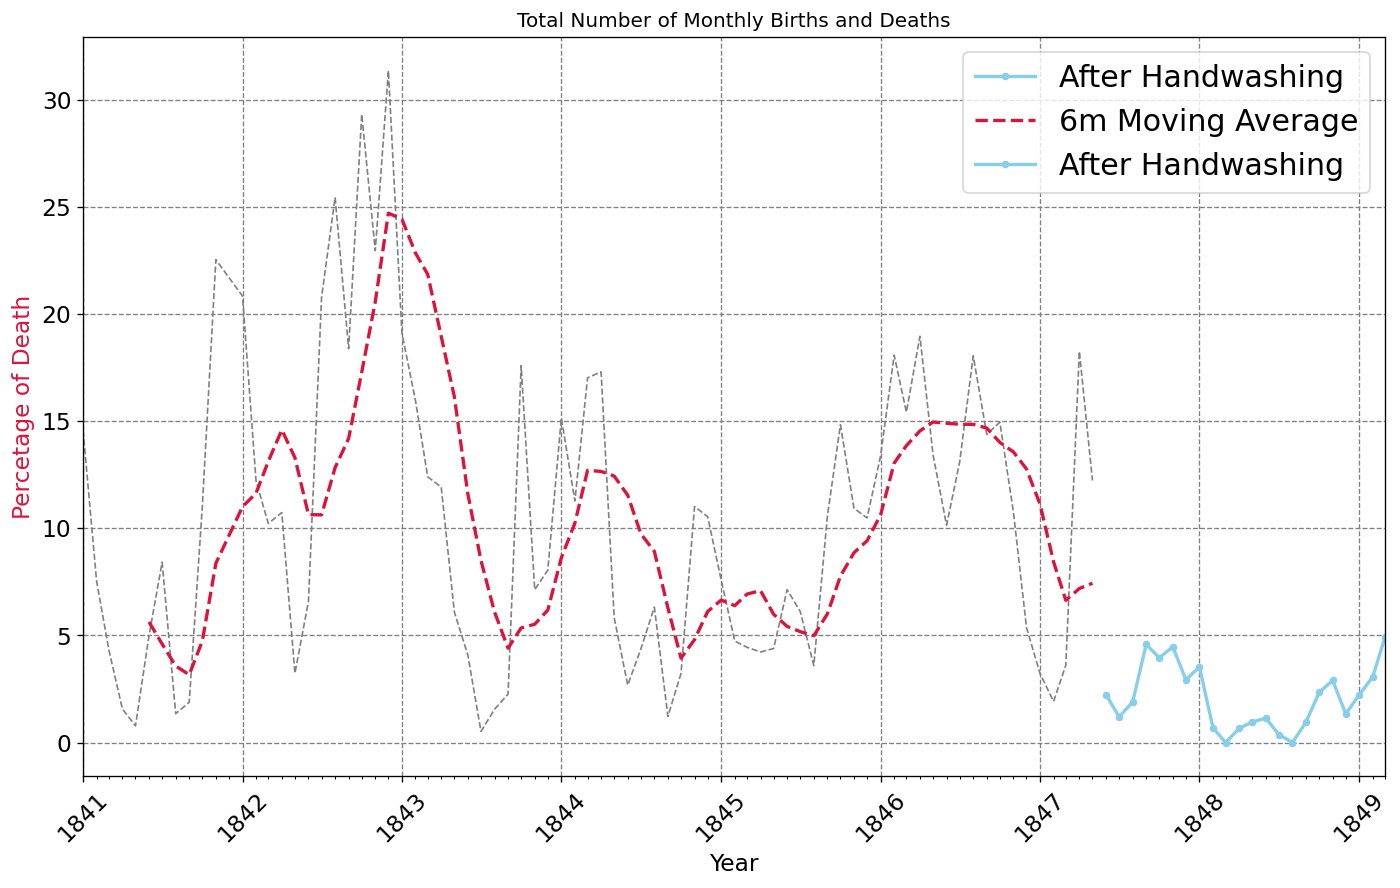

In [119]:

plt.figure(figsize=(14,8), dpi=120)
plt.xticks(fontsize = 14, rotation=45)
plt.yticks(fontsize=14)
plt.title('Total Number of Monthly Births and Deaths')

# Get the current axes for the plot
ax = plt.gca()

# Add grid lines to the plot with a dashed style
ax.grid(color='grey', linestyle='--')

# Set the x-axis limits to the min and max dates in df_monthly
ax.set_xlim([df_monthly.date.min(), df_monthly.date.max()])
ax.xaxis.set_major_locator(mdates.YearLocator()) # Set major tick locations to yearly intervals
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y')) # Format major tick labels to display only the year
ax.xaxis.set_minor_locator(mdates.MonthLocator()) # Set minor tick locations to monthly intervals

# Set x-axis label and font size
ax.set_xlabel('Year', fontsize = 14)
# Set y-axis label, color, and font size
ax.set_ylabel('Percetage of Death', color = 'crimson', fontsize = 14)

# Plot the death rate before handwashing as a thin dashed gray line
before_handwash_line, = plt.plot(before_handwash_df.date, before_handwash_df.pct__deaths, color = 'gray', linewidth=1, linestyle='--', label='Before Handwashing')

# Plot the 6-month moving average as a thicker crimson dashed line
monthly_avg_line, = plt.plot(moving_avg_6mon.date, moving_avg_6mon.df_death_rate_6mo, color = 'crimson', linewidth=2, linestyle='--', label='6m Moving Average')

# Plot the death rate after handwashing as a skyblue line with round markers
before_handwash_line, = plt.plot(after_handwash_df.date, after_handwash_df.pct__deaths, color = 'skyblue', linewidth=2, marker='.', markersize=7, label='After Handwashing')

# Add a legend to the plot with specified font size
plt.legend(handles=[before_handwash_line, monthly_avg_line, before_handwash_line],fontsize=18)

# Display the plot
plt.show()

### Statistics - Calculate the Difference in the Average Monthly Death Rate

**Challenge**:
* What was the average percentage of monthly deaths before handwashing?
* What was the average percentage of monthly deaths after handwashing was made obligatory?
* By how much did handwashing reduce the average chance of dying in childbirth in percentage terms?
* How do these numbers compare to the average for all the 1840s that we calculated earlier?
* How many times lower are the chances of dying after handwashing compared to before?

In [32]:
# Display the last 5 rows of the df_monthly data before May 30, 1847
df_monthly[df_monthly.date <= '1847-05-30'].tail(5)

,date,births,deaths,pct__deaths,df_death_rate_6mo
71,1847-01-01,311,10,3.22,11.13
72,1847-02-01,312,6,1.92,8.44
73,1847-03-01,305,11,3.61,6.64
74,1847-04-01,312,57,18.27,7.19
75,1847-05-01,294,36,12.24,7.44


In [33]:
# Display the first 5 rows of the df_monthly data after May 30, 1847
df_monthly[df_monthly.date > '1847-05-30'].head(5)

,date,births,deaths,pct__deaths,df_death_rate_6mo
76,1847-06-01,268,6,2.24,6.92
77,1847-07-01,250,3,1.20,6.58
78,1847-08-01,264,5,1.89,6.58
79,1847-09-01,262,12,4.58,6.74
80,1847-10-01,278,11,3.96,4.35


In [34]:
# Calculate the overall average death rate before handwashing (total deaths / total births * 100), rounded to 2 decimal places
before_handwash = round((before_handwash_df.deaths.sum() / before_handwash_df.births.sum() * 100), 2)
# Calculate the overall average death rate after handwashing (total deaths / total births * 100), rounded to 2 decimal places
after_handwash = round((after_handwash_df.deaths.sum() / after_handwash_df.births.sum() * 100), 2)

# Print the calculated average death rates before and after handwashing
print(f'{after_handwash} {before_handwash}')

2.15 10.53


**Outcome**: A lot of statistical tests rely on comparing features of distributions, like the mean. We see that the average death rate before handwashing was 10.5%. After handwashing was made obligatory, the average death rate was 2.11%. The difference is massive. Handwashing decreased the average death rate by 8.4%, a 5x improvement.

In [118]:
# Calculate the average monthly percentage of deaths before handwashing from the 'pct__deaths' column
avg_prob_before = before_handwash_df.pct__deaths.mean()
# Print the average monthly percentage of deaths before handwashing, rounded to 2 decimal places
print(f'Chance of death during childbirth before handwashing: {round(avg_prob_before,2)}%.')

# Calculate the average monthly percentage of deaths after handwashing from the 'pct__deaths' column
avg_prob_after = after_handwash_df.pct__deaths.mean()
# Print the average monthly percentage of deaths after handwashing, rounded to 2 decimal places
print(f'Chance of death during childbirth AFTER handwashing: {round(avg_prob_after,2)}%.')

# Calculate the difference in average monthly percentage of deaths
mean_diff = avg_prob_before - avg_prob_after
# Print how much handwashing reduced the monthly proportion of deaths, rounded to 2 decimal places
print(f'Handwashing reduced the monthly proportion of deaths by {round(mean_diff,2)}%!')

# Calculate how many times lower the chances of dying are after handwashing compared to before
times = avg_prob_before / avg_prob_after
# Print the improvement factor, formatted to 2 decimal places
print(f'This is a {times:.2}x improvement!')

Chance of death during childbirth before handwashing: 10.5%.
Chance of death during childbirth AFTER handwashing: 2.11%.
Handwashing reduced the monthly proportion of deaths by 8.4%!
This is a 5.0x improvement!


### Use Box Plots to Show How the Death Rate Changed Before and After Handwashing

**Challenge**:
* Use [NumPy's `.where()` function](https://numpy.org/doc/stable/reference/generated/numpy.where.html) to add a column to `df_monthly` that shows if a particular date was before or after the start of handwashing.
* Then use plotly to create box plot of the data before and after handwashing.
* How did key statistics like the mean, max, min, 1st and 3rd quartile changed as a result of the new policy?



In [36]:
# Add a new column 'handwash_status' to df_monthly
# Use np.where to assign 'No' if the date is before May 30, 1847, and 'Yes' otherwise
df_monthly['handwash_status'] = np.where(df_monthly.date < '1847-05-30', 'No', 'Yes')

In [37]:
# Display the entire df_monthly DataFrame to show the new 'handwash_status' column
df_monthly

,date,births,deaths,pct__deaths,df_death_rate_6mo,handwash_status
0,1841-01-01,254,37,14.57,NaN,No
1,1841-02-01,239,18,7.53,NaN,No
2,1841-03-01,277,12,4.33,NaN,No
3,1841-04-01,255,4,1.57,NaN,No
4,1841-05-01,255,2,0.78,NaN,No
...,...,...,...,...,...,...
93,1848-11-01,310,9,2.90,1.28,Yes
94,1848-12-01,373,5,1.34,1.32,Yes
95,1849-01-01,403,9,2.23,1.63,Yes
96,1849-02-01,389,12,3.08,2.14,Yes


In [38]:
# Create a box plot using Plotly Express
# x-axis: 'handwash_status', y-axis: 'pct__deaths', color: 'handwash_status' for differentiation
# title: 'How Have the Stats Changed with Handwashing?'
box = px.box(df_monthly,
             x='handwash_status',
             y='pct__deaths',
             color='handwash_status',
             title='How Have the Stats Changed with Handwashing?')

# Update the layout to set x-axis and y-axis titles
box.update_layout(xaxis_title='Washing Hands?',
                  yaxis_title='Percentage of Monthly Deaths')

# Display the box plot
box.show()

**Outcome**: The plot shows us the same data as our Matplotlib chart, but from a different perspective. Here we also see the massive spike in deaths in late 1842. Over 30% of women who gave birth that month died in hospital. What we also see in the box plot is how not only did the average death rate come down, but so did the overall range

### Use Histograms to Visualise the Monthly Distribution of Outcomes

**Challenge**: Create a [plotly histogram](https://plotly.com/python/histograms/) to show the monthly percentage of deaths.

* Use docs to check out the available parameters. Use the [`color` parameter](https://plotly.github.io/plotly.py-docs/generated/plotly.express.histogram.html) to display two overlapping histograms.
* The time period of handwashing is shorter than not handwashing. Change `histnorm` to `percent` to make the time periods comparable.
* Make the histograms slighlty transparent
* Experiment with the number of bins on the histogram. Which number work well in communicating the range of outcomes?
* Just for fun, display your box plot on the top of the histogram using the `marginal` parameter.

To create our histogram, we once again make use of the color parameter. This creates two separate histograms for us. When we set the opacity to 0.6 or so we can clearly see how the histograms overlap. The trick to getting a sensible-looking histogram when you have a very different number of observations is to set the histnorm to 'percent'. That way the histogram with more observations won't completely overshadow the shorter series.

In [62]:
# Create a histogram using Plotly Express
# x-axis: 'pct__deaths', color: 'handwash_status' to create overlapping histograms
# opacity: 0.6 for transparency, nbins: 30 for bin count
# marginal: 'box' to add a box plot on top, barmode: 'overlay' to stack bars
# histnorm: 'percent' to normalize histogram heights for comparison
fig = px.histogram(df_monthly, x = 'pct__deaths', color="handwash_status", opacity=0.6, nbins=30, marginal="box", barmode='overlay', histnorm='percent')

# Update the layout to set x-axis and y-axis titles
fig.update_layout(xaxis_title='Proportion of Monthly Deaths',
                   yaxis_title='Count')
# Display the histogram
fig.show()

Now, we have only about 98 data points or so, so our histogram looks a bit jagged. It's not a smooth bell-shaped curve. However, we can estimate what the distribution would look like with a Kernel Density Estimate (KDE)

### Use a Kernel Density Estimate (KDE) to visualise a smooth distribution

**Challenge**: Use [Seaborn's `.kdeplot()`](https://seaborn.pydata.org/generated/seaborn.kdeplot.html) to create two kernel density estimates of the `pct_deaths`, one for before handwashing and one for after.

* Use the `shade` parameter to give your two distributions different colours.
* What weakness in the chart do you see when you just use the default parameters?
* Use the `clip` parameter to address the problem.


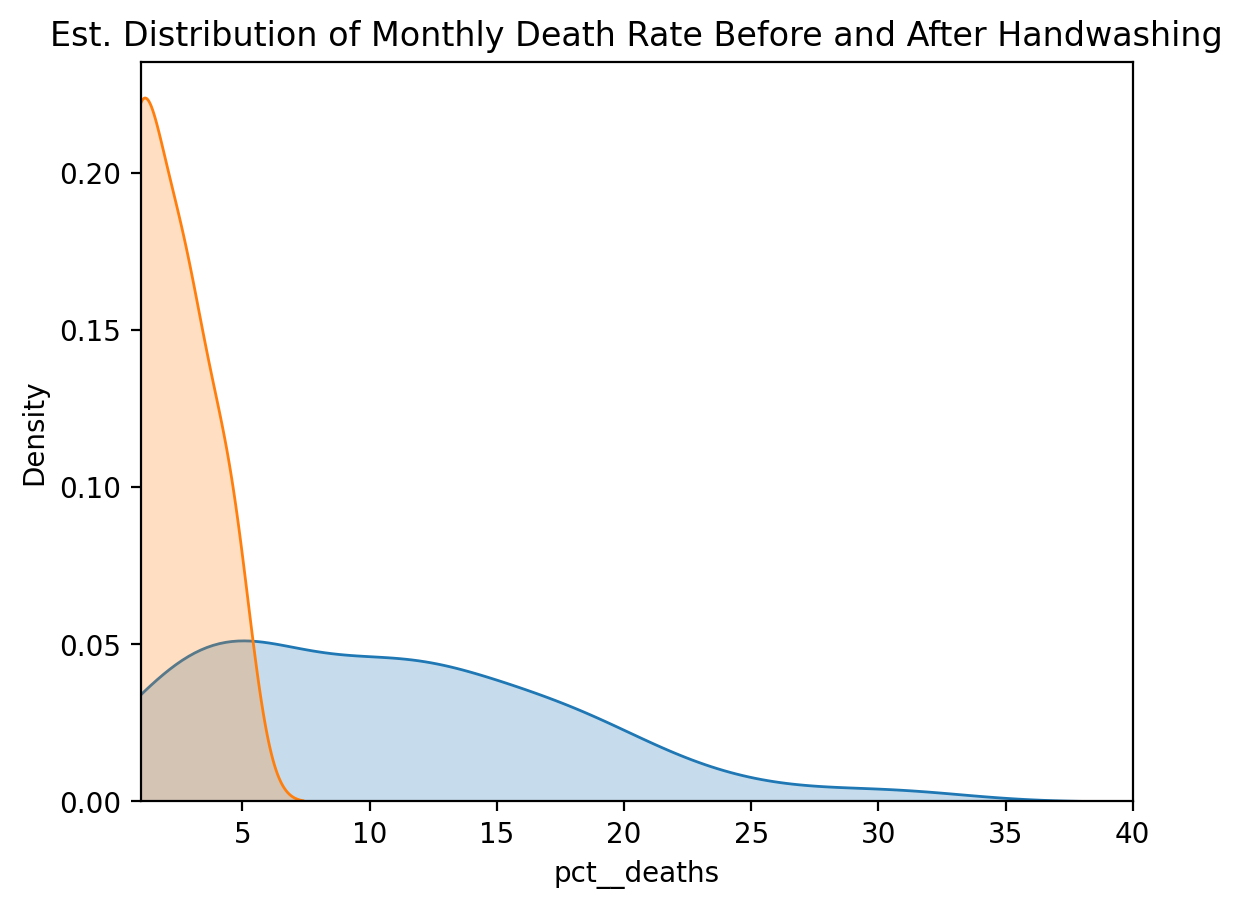

In [108]:
plt.figure(dpi=200)
# Create a Kernel Density Estimate plot for 'pct__deaths' before handwashing with shaded area
sns.kdeplot(before_handwash_df.pct__deaths, fill=True)
# Create a Kernel Density Estimate plot for 'pct__deaths' after handwashing with shaded area
sns.kdeplot(after_handwash_df.pct__deaths, fill=True)
# Add a title to the plot
plt.title('Est. Distribution of Monthly Death Rate Before and After Handwashing')

# Set the x-axis limits to focus on relevant death rates (1% to 40%)
plt.xlim(1, 40)

# Display the plot
plt.show()

**Outcome**: Now that we have an idea of what the two distributions look like, we can further strengthen our argument for handwashing by using a statistical test. We can test whether our distributions ended up looking so different purely by chance (i.e., the lower death rate is just an accident) or if the 8.4% difference in the average death rate is statistically significant.

### Use a T-Test to Show Statistical Significance

**Challenge**: Use a t-test to determine if the differences in the means are statistically significant or purely due to chance.

If the p-value is less than 1% then we can be 99% certain that handwashing has made a difference to the average monthly death rate.

* Import `stats` from scipy
* Use the [`.ttest_ind()` function](https://docs.scipy.org/]doc/scipy/reference/generated/scipy.stats.ttest_ind.html) to calculate the t-statistic and the p-value
* Is the difference in the average proportion of monthly deaths statistically significant at the 99% level?



In [109]:
# Import the stats module from the scipy library, which contains statistical functions
from scipy import stats

In [120]:
# Perform an independent samples t-test between 'pct__deaths' before and after handwashing
# The ttest_ind function returns the t-statistic and the p-value
t_stat, p_value = stats.ttest_ind(before_handwash_df.pct__deaths, after_handwash_df.pct__deaths)

print(f'p-palue is {p_value:.10f}')
print(f't-statstic is {t_stat:.4}')

p-palue is 0.0000002990
t-statstic is 5.511


What do you conclude from your analysis, Doctor? 😊

<img src=https://i.imgur.com/rvjNVzQ.gif>

**Outcome**:

**Significant Reduction in Death Rate**: The average monthly death rate dropped dramatically after handwashing was implemented. Before handwashing, the average monthly death rate was approximately 10.53%, while after its implementation, it fell to about 2.15%.

**Statistical Significance**: The t-test conducted gave a p-value of 0.0000002990, which is significantly less than 0.01 (1%). This indicates that the observed difference in death rates is statistically significant at the 99% level. In simpler terms, it is highly improbable that this reduction in deaths happened by chance.

**Substantial Improvement**: Handwashing reduced the average chance of dying in childbirth by approximately 8.39% (from 10.53% to 2.15%), representing a nearly 5-fold improvement. The distributions of monthly death rates also clearly show a shift to much lower values after handwashing.